# 02a — Data Preparation & Feature Handling

Load raw feature CSVs, explore feature distributions (EDA), then build the curated feature catalog.
Saves artifacts (df_merged, catalog, feature prompt) for downstream notebooks.

## 0. Imports & Setup

In [1]:
import sys
sys.path.insert(0, '..')

import os
import json
import time
import warnings
from pathlib import Path
from typing import TypedDict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cosine as cosine_dist
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore', category=FutureWarning)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

# Optional: CLAP via HuggingFace transformers
try:
    from transformers import ClapModel, ClapProcessor
    import librosa
    CLAP_AVAILABLE = True
    print('CLAP available via transformers')
except ImportError:
    CLAP_AVAILABLE = False
    print('CLAP not available — install: uv add transformers librosa')

# Optional: Sentence-Transformers for text embeddings
try:
    from sentence_transformers import SentenceTransformer
    SBERT_AVAILABLE = True
    print('sentence-transformers available')
except ImportError:
    SBERT_AVAILABLE = False
    print('sentence-transformers not available — install: uv add sentence-transformers')

# Optional: Gemini SDK for LLM calls
try:
    from google import genai
    from google.genai import types as genai_types
    GEMINI_AVAILABLE = True
    print('google-genai SDK available')
except ImportError:
    GEMINI_AVAILABLE = False
    print('google-genai SDK not available — install: uv add google-genai')

# Project config
from atdj.config import PROCESSED_DIR, DATA_DIR

# LLM setup — Gemini
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
GEMINI_MODEL = os.getenv('GEMINI_MODEL', 'gemini-2.0-flash')
LLM_READY = GEMINI_AVAILABLE and GEMINI_API_KEY is not None
if LLM_READY:
    print(f'LLM ready: model={GEMINI_MODEL}')
else:
    print('LLM not ready — set GEMINI_API_KEY in .env to enable Methods 2A/2B/3')


def llm_chat(client, system: str, user_message: str, max_tokens: int = 2000) -> str:
    """Unified LLM call via Gemini with retry on rate limits."""
    for attempt in range(4):
        try:
            response = client.models.generate_content(
                model=GEMINI_MODEL,
                contents=user_message,
                config=genai_types.GenerateContentConfig(
                    system_instruction=system if system else None,
                    max_output_tokens=max_tokens,
                ),
            )
            return response.text.strip()
        except Exception as e:
            if '429' in str(e) and attempt < 3:
                wait = 15 * (attempt + 1)
                print(f'  Rate limited, waiting {wait}s (attempt {attempt+1}/3)...')
                time.sleep(wait)
            else:
                raise


print(f'\nDATA_DIR: {DATA_DIR}')

CLAP available via transformers
sentence-transformers available
google-genai SDK available
LLM ready: model=gemini-2.0-flash

DATA_DIR: c:\Users\Vanessa\Desktop\Columbia\Spring 26\GenAI\Project\genai_atdj\notebooks\..\data


## 1. Data Loading & Merging

In [2]:
# Paths to feature files
FEATURES_DIR = Path(PROCESSED_DIR) / 'features_exp'
ESSENTIA_CSV = FEATURES_DIR / 'extra_features' / '200_songs_sample' / 'essentia_extra_sample200.csv'
LIBROSA_CSV  = FEATURES_DIR / 'extra_features' / '200_songs_sample' / 'librosa_sample200.csv'
RAW_AUDIO_DIR = Path(DATA_DIR) / 'raw'  # for CLAP audio encoding (if available)

print(f'Essentia CSV exists: {ESSENTIA_CSV.exists()}')
print(f'Librosa CSV exists:  {LIBROSA_CSV.exists()}')
print(f'Raw audio dir exists: {RAW_AUDIO_DIR.exists()}')

Essentia CSV exists: True
Librosa CSV exists:  True
Raw audio dir exists: True


In [3]:
# Load CSVs — headers on row 0 (no title row to skip)
df_ess = pd.read_csv(ESSENTIA_CSV)
df_lib = pd.read_csv(LIBROSA_CSV)

print(f'Essentia: {df_ess.shape[0]} songs × {df_ess.shape[1]} features')
print(f'Librosa:  {df_lib.shape[0]} songs × {df_lib.shape[1]} features')
print(f'\nEssentia columns: {list(df_ess.columns[:10])} ...')
print(f'Librosa columns:  {list(df_lib.columns[:10])} ...')
print(f'Duplicated columns:  {set(df_ess.columns).intersection(set(df_lib.columns))}')

Essentia: 200 songs × 98 features
Librosa:  200 songs × 113 features

Essentia columns: ['collection', 'filename', 'duration', 'bpm', 'beats_count', 'onset_rate', 'danceability', 'key', 'scale', 'key_strength'] ...
Librosa columns:  ['collection', 'filename', 'sample_rate', 'duration_seconds', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std'] ...
Duplicated columns:  {'filename', 'collection'}


In [4]:
# Deduplicate by filename (cortinas repeat across volumes, keep first)
df_ess_dedup = df_ess.drop_duplicates(subset='filename', keep='first')
df_lib_dedup = df_lib.drop_duplicates(subset='filename', keep='first')
print(f'After dedup: Essentia {len(df_ess_dedup)}, Librosa {len(df_lib_dedup)}')

# Full outer join to keep all songs from both libraries
df_merged = df_ess_dedup.merge(df_lib_dedup, on=['collection','filename'], how='outer', suffixes=('_ess', '_lib')).rename(columns={"collection":"album"})
print(f'Merged (outer): {df_merged.shape[0]} songs x {df_merged.shape[1]} columns')

# Coverage summary
has_ess = df_merged.filter(like='_ess').notna().any(axis=1) | df_merged['bpm'].notna()
has_lib = df_merged.filter(like='_lib').notna().any(axis=1) | df_merged['duration_seconds'].notna()
print(f'  Has Essentia features: {has_ess.sum()}')
print(f'  Has Librosa features:  {has_lib.sum()}')
print(f'  Has both:              {(has_ess & has_lib).sum()}')

# Null summary
null_pct = df_merged.isnull().mean()
print(f'\nFeature coverage:')
print(f'  Columns with no nulls:  {(null_pct == 0).sum()}')
print(f'  Columns with <25% nulls:  {(null_pct < 0.25).sum()}')
print(f'  Columns with 25-75% nulls: {((null_pct >= 0.25) & (null_pct < 0.75)).sum()}')
print(f'  Columns with >75% nulls:  {(null_pct >= 0.75).sum()}')

# Merge catalog metadata (style, decade, orchestra, singer)
CATALOG_PATH = DATA_DIR / 'catalog.csv'
if CATALOG_PATH.exists():
    df_catalog = pd.read_csv(CATALOG_PATH)
    meta_cols = ['album', 'filename', 'style', 'decade', 'orchestra', 'singer']
    meta_cols = [c for c in meta_cols if c in df_catalog.columns]
    df_catalog_slim = df_catalog[meta_cols].copy()

    pre_cols = df_merged.shape[1]
    df_merged = df_merged.merge(df_catalog_slim, on=['album','filename'], how='left')
    print(f'\nAfter catalog merge: {df_merged.shape[0]} songs x {df_merged.shape[1]} columns (+{df_merged.shape[1] - pre_cols} metadata)')

    print(f'Style distribution:')
    print(df_merged['style'].value_counts(dropna=False).to_string())
else:
    print('WARNING: catalog.csv not found')

# Categorical columns — string metadata + audio-extracted categoricals
# Always preserved, never enter numeric feature selection
CATEGORICAL_COLS = ['album', 'filename', 'style', 'decade', 'orchestra', 'singer', 'key', 'scale']
CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in df_merged.columns]
print(f'\nCATEGORICAL_COLS ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}')

# Resolve audio file paths (raw/ and cortinas/)
RAW_AUDIO_DIR = DATA_DIR / 'raw'
CORTINA_AUDIO_DIR = DATA_DIR / 'cortinas'
raw_mp3s = {f.name: f for f in RAW_AUDIO_DIR.glob('*.mp3') if not f.name.startswith('._')}
cortina_mp3s = {f.name: f for f in CORTINA_AUDIO_DIR.rglob('*.mp3') if not f.name.startswith('._')}
all_audio_map = {**cortina_mp3s, **raw_mp3s}  # raw takes precedence
audio_found = df_merged['filename'].isin(all_audio_map).sum()
print(f'\nAudio files found: {audio_found}/{len(df_merged)} songs')

After dedup: Essentia 184, Librosa 184
Merged (outer): 184 songs x 209 columns
  Has Essentia features: 184
  Has Librosa features:  184
  Has both:              184

Feature coverage:
  Columns with no nulls:  209
  Columns with <25% nulls:  209
  Columns with 25-75% nulls: 0
  Columns with >75% nulls:  0

After catalog merge: 184 songs x 213 columns (+4 metadata)
Style distribution:
style
tango            91
NaN              67
vals             10
milonga           9
cortina           6
arr. en tango     1

CATEGORICAL_COLS (8): ['album', 'filename', 'style', 'decade', 'orchestra', 'singer', 'key', 'scale']

Audio files found: 172/184 songs


Total tanda-eligible tracks: 178
Unique (style, orchestra, singer) combinations:66

── Distribution of combo sizes ──
  <3 (no tanda)                    57 combos  (  69songs)
  3 (forced)                        2 combos  (   6songs)
  4 (1 tanda,no choice)             3 combos  (  12songs)
  5-7 (some choice)                 4 combos  (  24songs)
  8-10 (good)                       0 combos  (   0songs)
  10+(rich)                         0 combos  (   0songs)


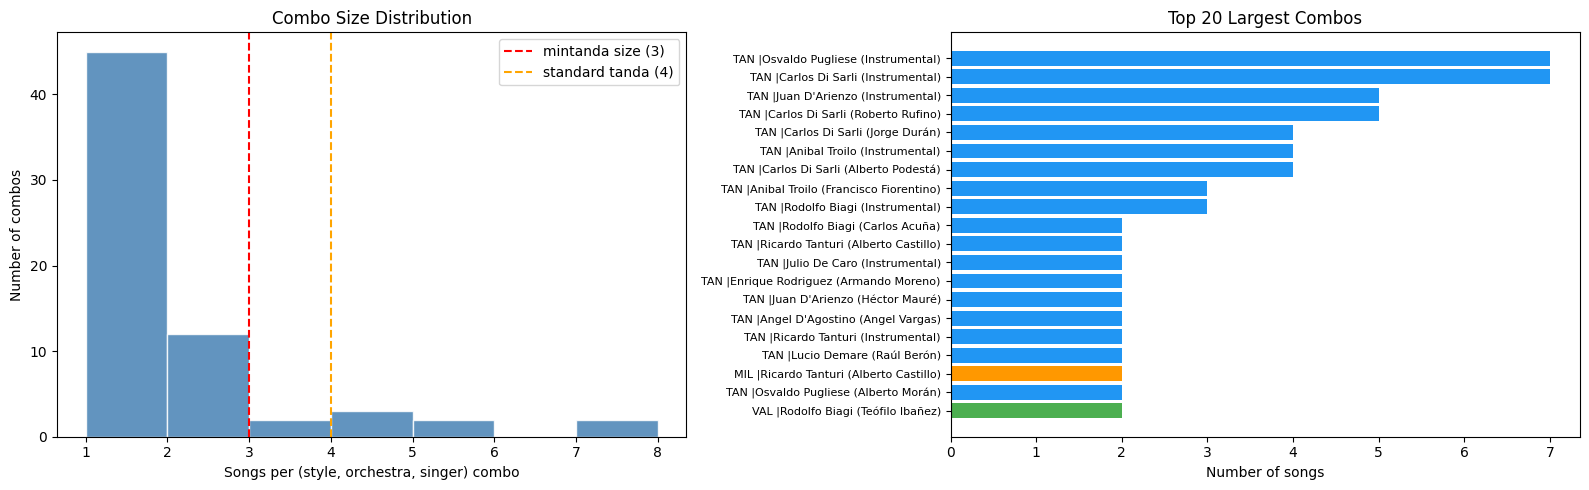

In [5]:
# Exclude cortinas — they don't form tandas
df_tracks = df_merged[df_merged['style'] != 'cortina'].copy()

# Normalize singer: NaN → "Instrumental"
df_tracks['singer_clean'] = df_tracks['singer'].fillna('Instrumental')

combo = (
    df_tracks
    .groupby(['style', 'orchestra', 'singer_clean'])
    .size()
    .reset_index(name='n_songs')
    .sort_values('n_songs', ascending=False)
)

print(f'Total tanda-eligible tracks: {len(df_tracks)}')
print(f'Unique (style, orchestra, singer) combinations:{len(combo)}')
print(f'\n── Distribution of combo sizes ──')
bins = pd.cut(combo['n_songs'], bins=[0, 2, 3, 4, 7, 10, 100],
            labels=['<3 (no tanda)', '3 (forced)', '4 (1 tanda,no choice)',
                    '5-7 (some choice)', '8-10 (good)', '10+(rich)'])
bin_counts = bins.value_counts().sort_index()
for label, count in bin_counts.items():
    songs_in_bin = combo.loc[bins == label, 'n_songs'].sum()
    print(f'  {label:30s}  {count:3d} combos  ({songs_in_bin:4d}songs)')

# Visual
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: histogram of combo sizes
axes[0].hist(combo['n_songs'], bins=range(1,
combo['n_songs'].max() + 2),
            color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(x=3, color='red', linestyle='--', label='mintanda size (3)')
axes[0].axvline(x=4, color='orange', linestyle='--',
label='standard tanda (4)')
axes[0].set_xlabel('Songs per (style, orchestra, singer) combo')
axes[0].set_ylabel('Number of combos')
axes[0].set_title('Combo Size Distribution')
axes[0].legend()

# Right: top 20 largest combos
top20 = combo.head(20)
labels = top20.apply(lambda r: f"{r['style'][:3].upper()} |{r['orchestra']} ({r['singer_clean']})", axis=1)
colors = top20['style'].map({'tango': '#2196F3', 'vals':'#4CAF50', 'milonga': '#FF9800'}).fillna('gray')
axes[1].barh(range(len(top20)), top20['n_songs'].values,
color=colors.values)
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_xlabel('Number of songs')
axes[1].set_title('Top 20 Largest Combos')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 2. Feature EDA

Explore all numeric features before deciding what to include in the curated catalog.
This analysis informs feature selection for Section 3.

Total numeric columns: 205


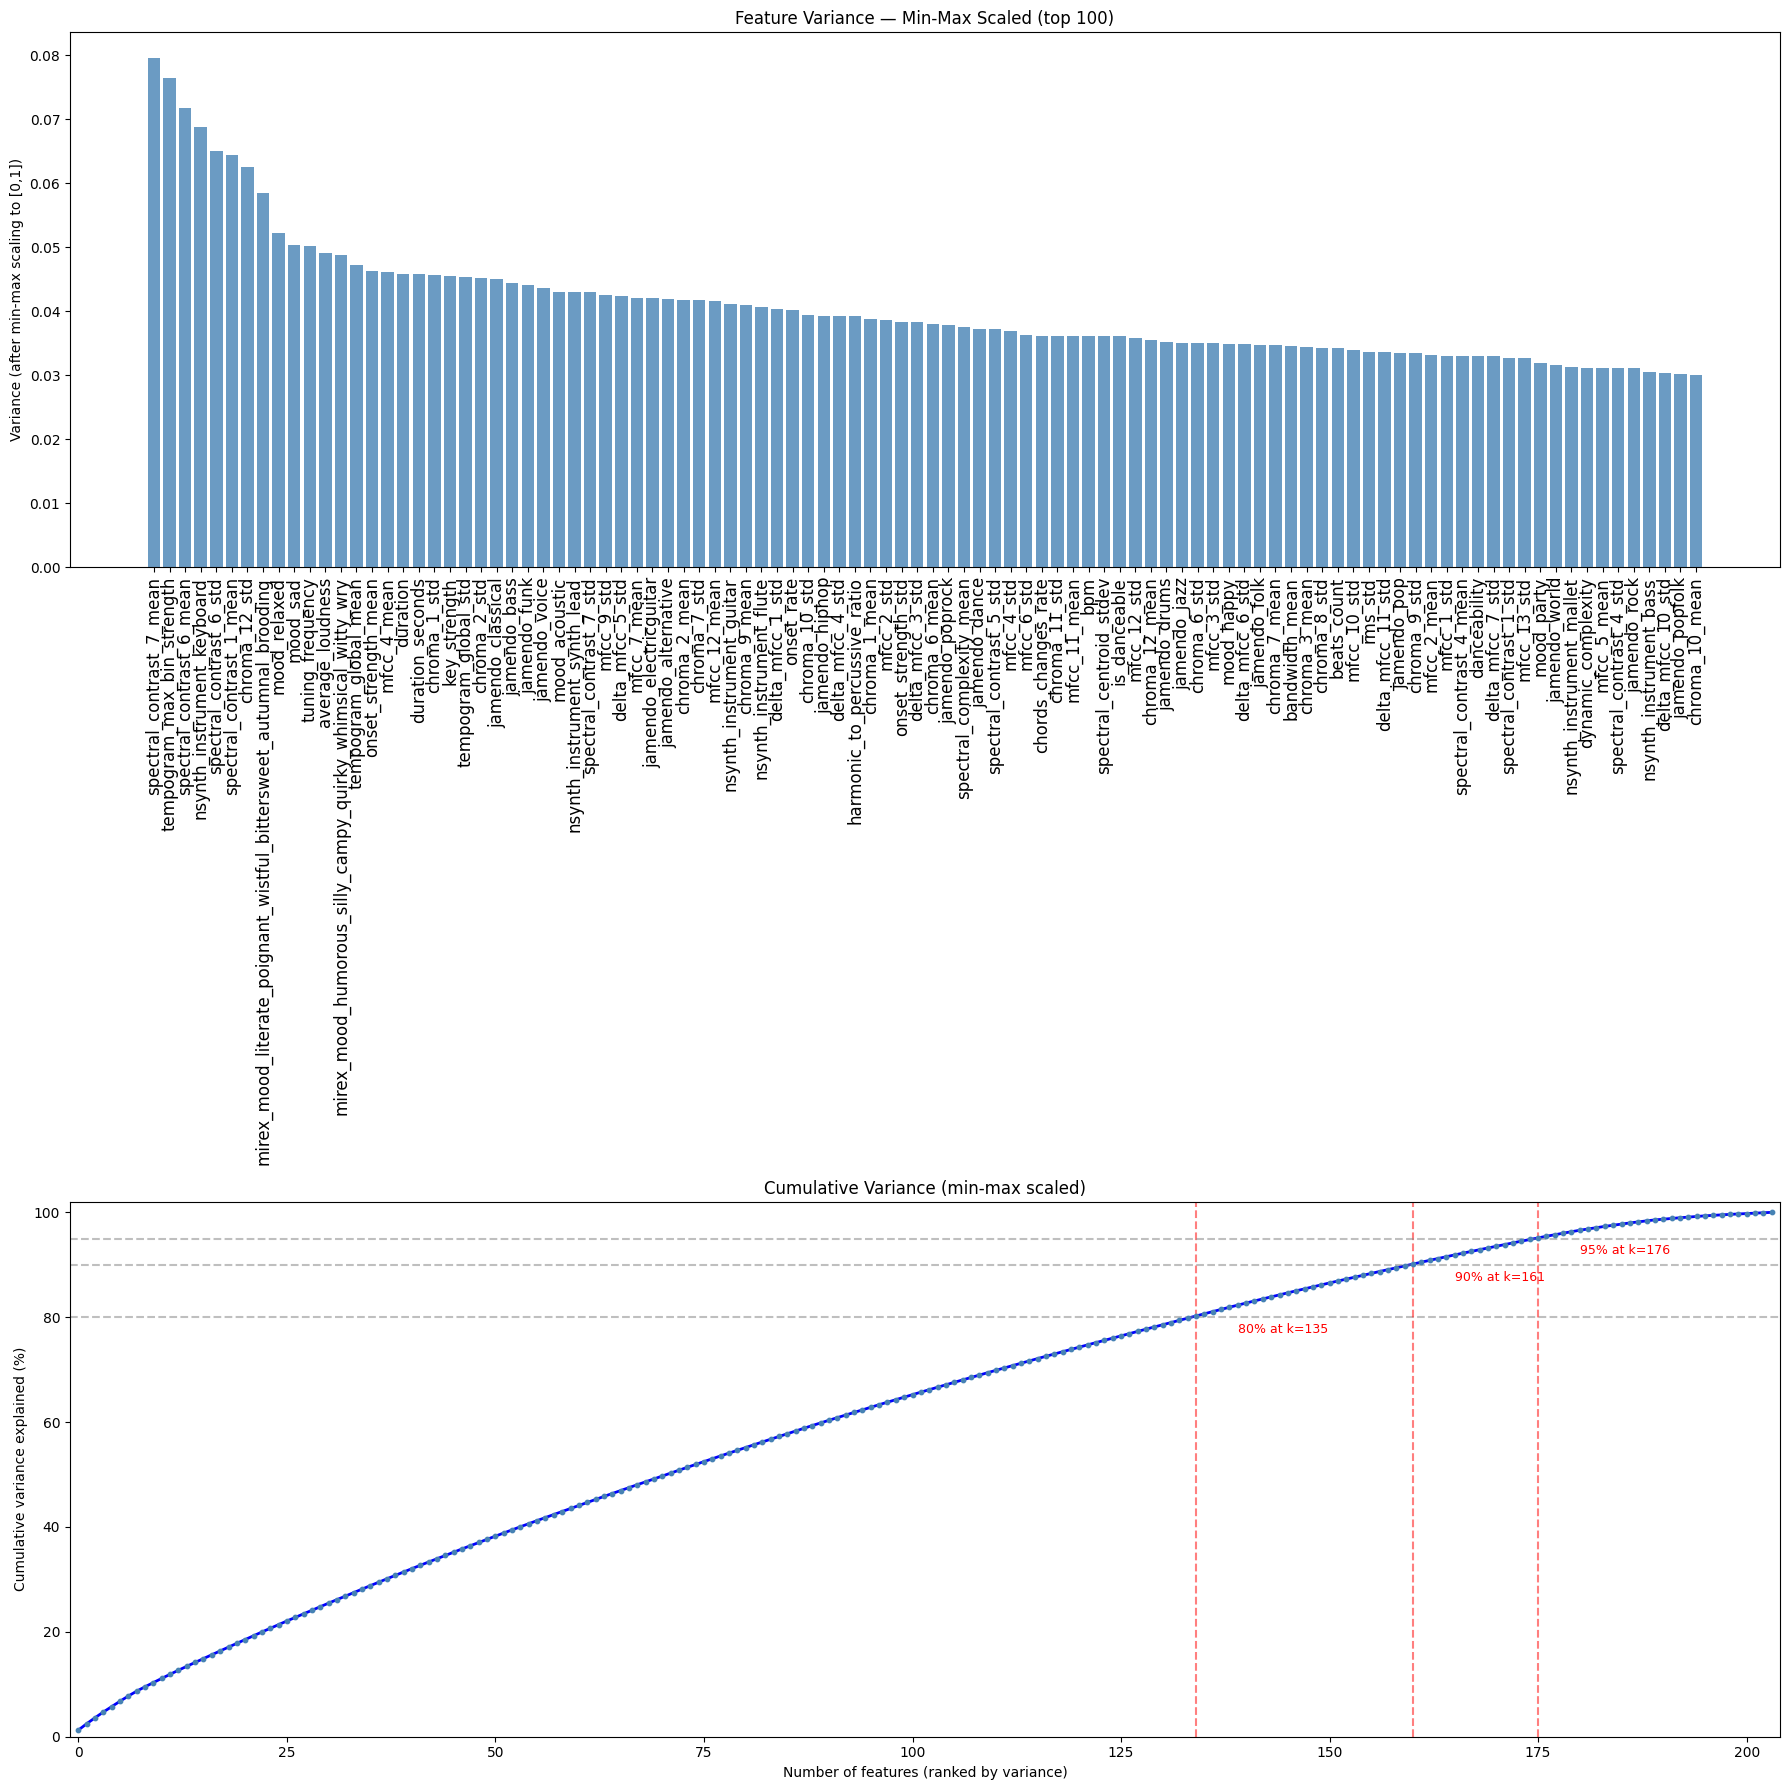

Total features: 204
Near-zero variance (<1e-4 after scaling):0
Top 135 features cover 80% of total variance
Top 161 features cover 90% of total variance
Top 176 features cover 95% of total variance


In [6]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# 2a. Variance analysis (min-max scaled)                         
# Scale all features to [0,1] first so variance comparison is unit-free.    

numeric_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if not c.startswith('Unnamed')]
print(f'Total numeric columns: {len(numeric_cols)}')

feat_for_var = df_merged[numeric_cols].dropna(axis=1, how='all') 
feat_for_var = feat_for_var.fillna(feat_for_var.mean())          
feat_for_var = feat_for_var.loc[:, feat_for_var.std() > 0]

# Detect binary features: only contain values in {0, 1}          
binary_cols = [c for c in feat_for_var.columns if                
feat_for_var[c].dropna().isin([0, 1]).all()]    
                                                                
# Min-max scale each feature to [0,1], then compare variance
feat_scaled = (feat_for_var - feat_for_var.min()) /(feat_for_var.max() - feat_for_var.min())
variances = feat_scaled.var().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 18))

# individual variance after min-max scaling (range: 0 to~0.25 max theoretical)
top_n = min(100, len(variances))
colors = ['#FF9800' if variances.index[i] in binary_cols else 'steelblue'for i in range(top_n)]
ax1.bar(range(top_n), variances.values[:top_n], color=colors, alpha=0.8)
ax1.set_xticks(range(top_n))
ax1.set_xticklabels(variances.index[:top_n], rotation=90, fontsize=12)
ax1.set_ylabel('Variance (after min-max scaling to [0,1])')
ax1.set_title(f'Feature Variance — Min-Max Scaled (top {top_n})')

# cumulative variance curve
cum_var = variances.cumsum() / variances.sum() * 100
ax2.plot(range(len(cum_var)), cum_var.values, 'b-', linewidth=2)
ax2.scatter(range(len(cum_var)), cum_var.values, s=10,
color='steelblue', zorder=3)
for threshold in [80, 90, 95]:
    idx = np.searchsorted(cum_var.values, threshold)
    if idx < len(cum_var):
        ax2.axhline(y=threshold, color='gray', linestyle='--',alpha=0.5)
        ax2.axvline(x=idx, color='red', linestyle='--',alpha=0.5)
        ax2.annotate(f'{threshold}% at k={idx+1}', xy=(idx,threshold),
                    xytext=(idx+5, threshold-3), fontsize=9,color='red')
ax2.set_xlabel('Number of features (ranked by variance)')
ax2.set_ylabel('Cumulative variance explained (%)')
ax2.set_title('Cumulative Variance (min-max scaled)')
ax2.set_xlim(-1, len(cum_var))
ax2.set_ylim(0, 102)

plt.tight_layout()
plt.show()

near_zero = variances[variances < 1e-4]
print(f'Total features: {len(variances)}')
print(f'Near-zero variance (<1e-4 after scaling):{len(near_zero)}')
if len(near_zero) > 0:
    for feat, var in near_zero.items():
        print(f'  {feat}: var={var:.2e}')
for t in [80, 90, 95]:
    k = np.searchsorted(cum_var.values, t) + 1
    print(f'Top {k} features cover {t}% of total variance')

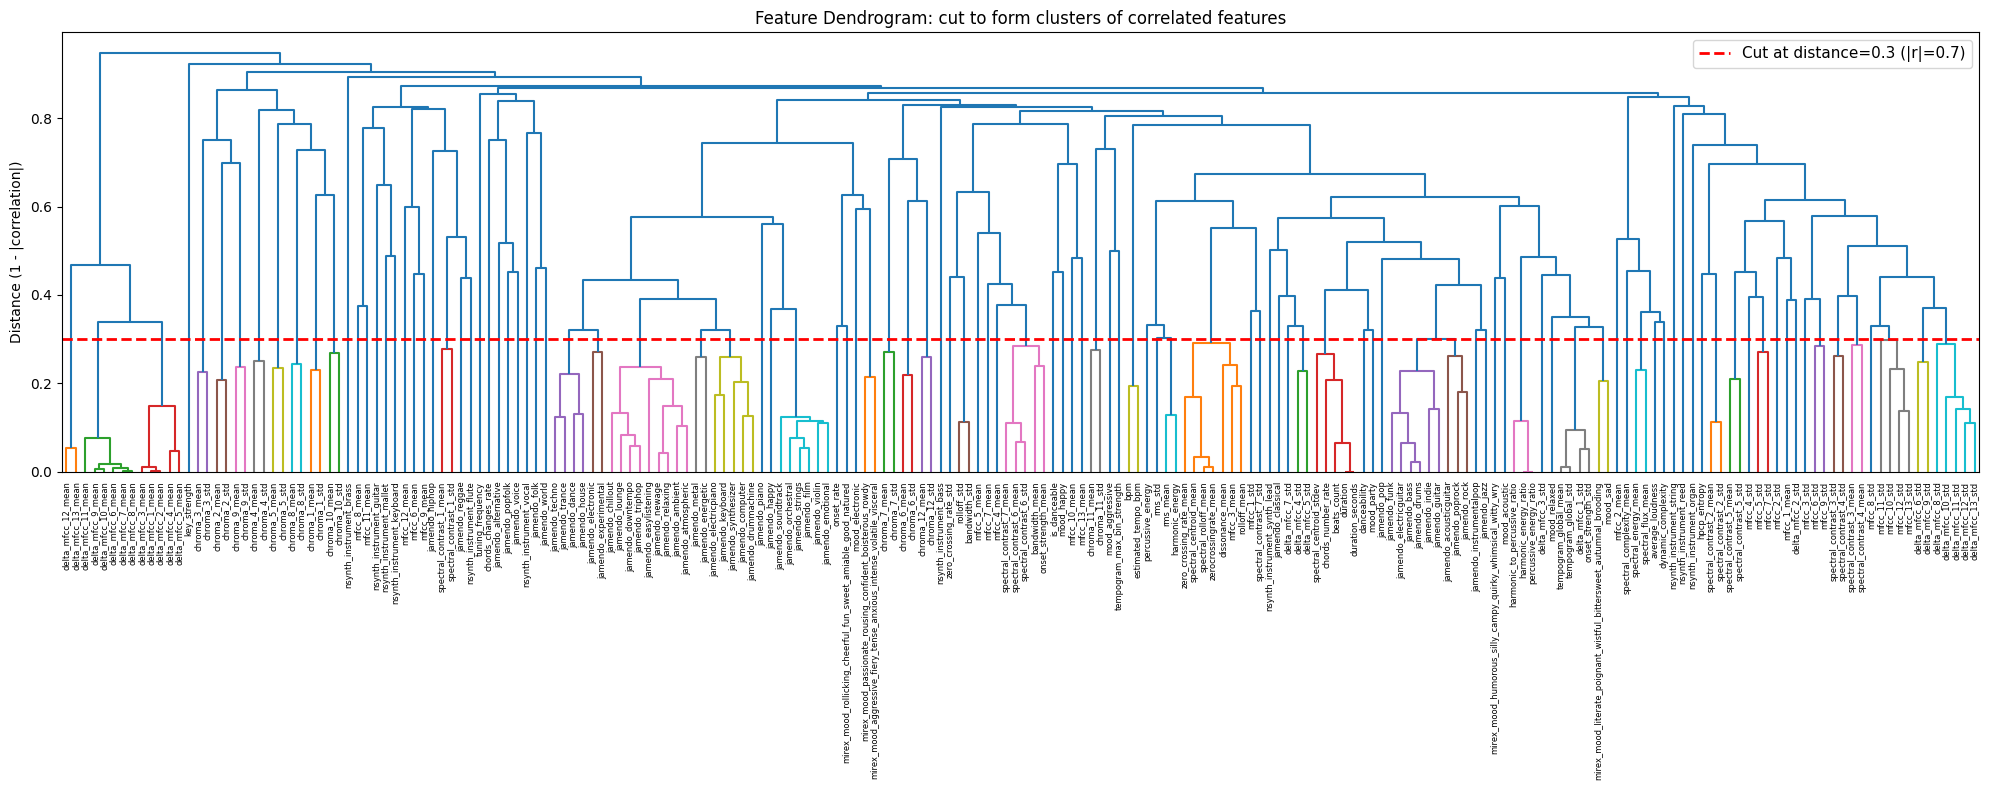

Cut threshold: distance=0.3 (merges features with |r| > 0.7)
Total features: 204
Clusters formed: 112
  Singletons (unique features): 67
  Multi-feature clusters: 45

Selected representatives: 112

Redundancy groups (45 clusters with >1 member):
  Cluster 49 (5 features) -> keep: spectral_contrast_7_mean
    drop: bandwidth_mean, onset_strength_mean, spectral_contrast_6_mean, spectral_contrast_6_std
  Cluster 20 (2 features) -> keep: spectral_contrast_1_mean
    drop: spectral_contrast_1_std
  Cluster 46 (2 features) -> keep: chroma_12_std
    drop: chroma_12_mean
  Cluster 83 (2 features) -> keep: mirex_mood_literate_poignant_wistful_bittersweet_autumnal_brooding
    drop: mood_sad
  Cluster 82 (4 features) -> keep: tempogram_global_mean
    drop: delta_mfcc_1_std, onset_strength_std, tempogram_global_std
  Cluster 71 (5 features) -> keep: duration
    drop: beats_count, chords_number_rate, duration_seconds, spectral_centroid_stdev
  Cluster 10 (2 features) -> keep: chroma_1_std
    d

In [7]:
# 2b. Feature selection via correlation clustering
# Cluster all features by correlation, then pick one representative per cluster.
# This removes redundancy while keeping original interpretable features.
# CATEGORICAL_COLS (string columns) are excluded — they bypass feature selection entirely.

from scipy.cluster.hierarchy import dendrogram, fcluster

feat_for_corr = df_merged[numeric_cols].dropna(axis=1, how='all')
feat_for_corr = feat_for_corr.fillna(feat_for_corr.mean())
feat_for_corr = feat_for_corr.loc[:, feat_for_corr.std() > 0]
corr_full = feat_for_corr.corr()

# Distance = 1 - |r|, so perfectly correlated features have distance 0
dist_full = squareform(np.clip(1 - corr_full.abs().values, 0, 2), checks=False)
link_full = linkage(dist_full, method='average')

# Plot dendrogram with cut line
CUT_THRESHOLD = 0.3  # features with |r| > 1- threshold get grouped together

fig, ax = plt.subplots(figsize=(20, 8))
dn = dendrogram(link_full, labels=corr_full.columns.tolist(), ax=ax,
                leaf_rotation=90, leaf_font_size=6,
                color_threshold=CUT_THRESHOLD)
ax.axhline(y=CUT_THRESHOLD, color='red', linestyle='--', linewidth=2,
           label=f'Cut at distance={CUT_THRESHOLD} (|r|={1-CUT_THRESHOLD:.1f})')
ax.set_ylabel('Distance (1 - |correlation|)')
ax.set_title('Feature Dendrogram: cut to form clusters of correlated features')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Cut the tree into clusters
cluster_labels = fcluster(link_full, t=CUT_THRESHOLD, criterion='distance')
feature_names = corr_full.columns.tolist()

# Build cluster summary: for each cluster, list members and pick representative
# Representative = the member with highest variance (after standardization)
cluster_info = []
for cid in sorted(set(cluster_labels)):
    members = [feature_names[i] for i in range(len(feature_names)) if cluster_labels[i] == cid]
    member_vars = {m: variances.get(m, 0) for m in members}
    representative = max(member_vars, key=member_vars.get)
    cluster_info.append({
        'cluster': cid,
        'size': len(members),
        'representative': representative,
        'rep_variance': round(member_vars[representative], 4),
        'members': ', '.join(sorted(members)),
    })

df_clusters = pd.DataFrame(cluster_info).sort_values('rep_variance', ascending=False)

print(f'Cut threshold: distance={CUT_THRESHOLD} (merges features with |r| > {1-CUT_THRESHOLD:.1f})')
print(f'Total features: {len(feature_names)}')
print(f'Clusters formed: {len(df_clusters)}')
print(f'  Singletons (unique features): {(df_clusters["size"] == 1).sum()}')
print(f'  Multi-feature clusters: {(df_clusters["size"] > 1).sum()}')
print(f'\nSelected representatives: {len(df_clusters)}')

SELECTED_FEATURES = df_clusters['representative'].tolist()

# Show clusters with >1 member (redundancy groups)
multi = df_clusters[df_clusters['size'] > 1].copy()
print(f'\nRedundancy groups ({len(multi)} clusters with >1 member):')
for _, row in multi.iterrows():
    print(f'  Cluster {row["cluster"]} ({row["size"]} features) -> keep: {row["representative"]}')
    dropped = [m.strip() for m in row['members'].split(',') if m.strip() != row['representative']]
    print(f'    drop: {", ".join(dropped)}')

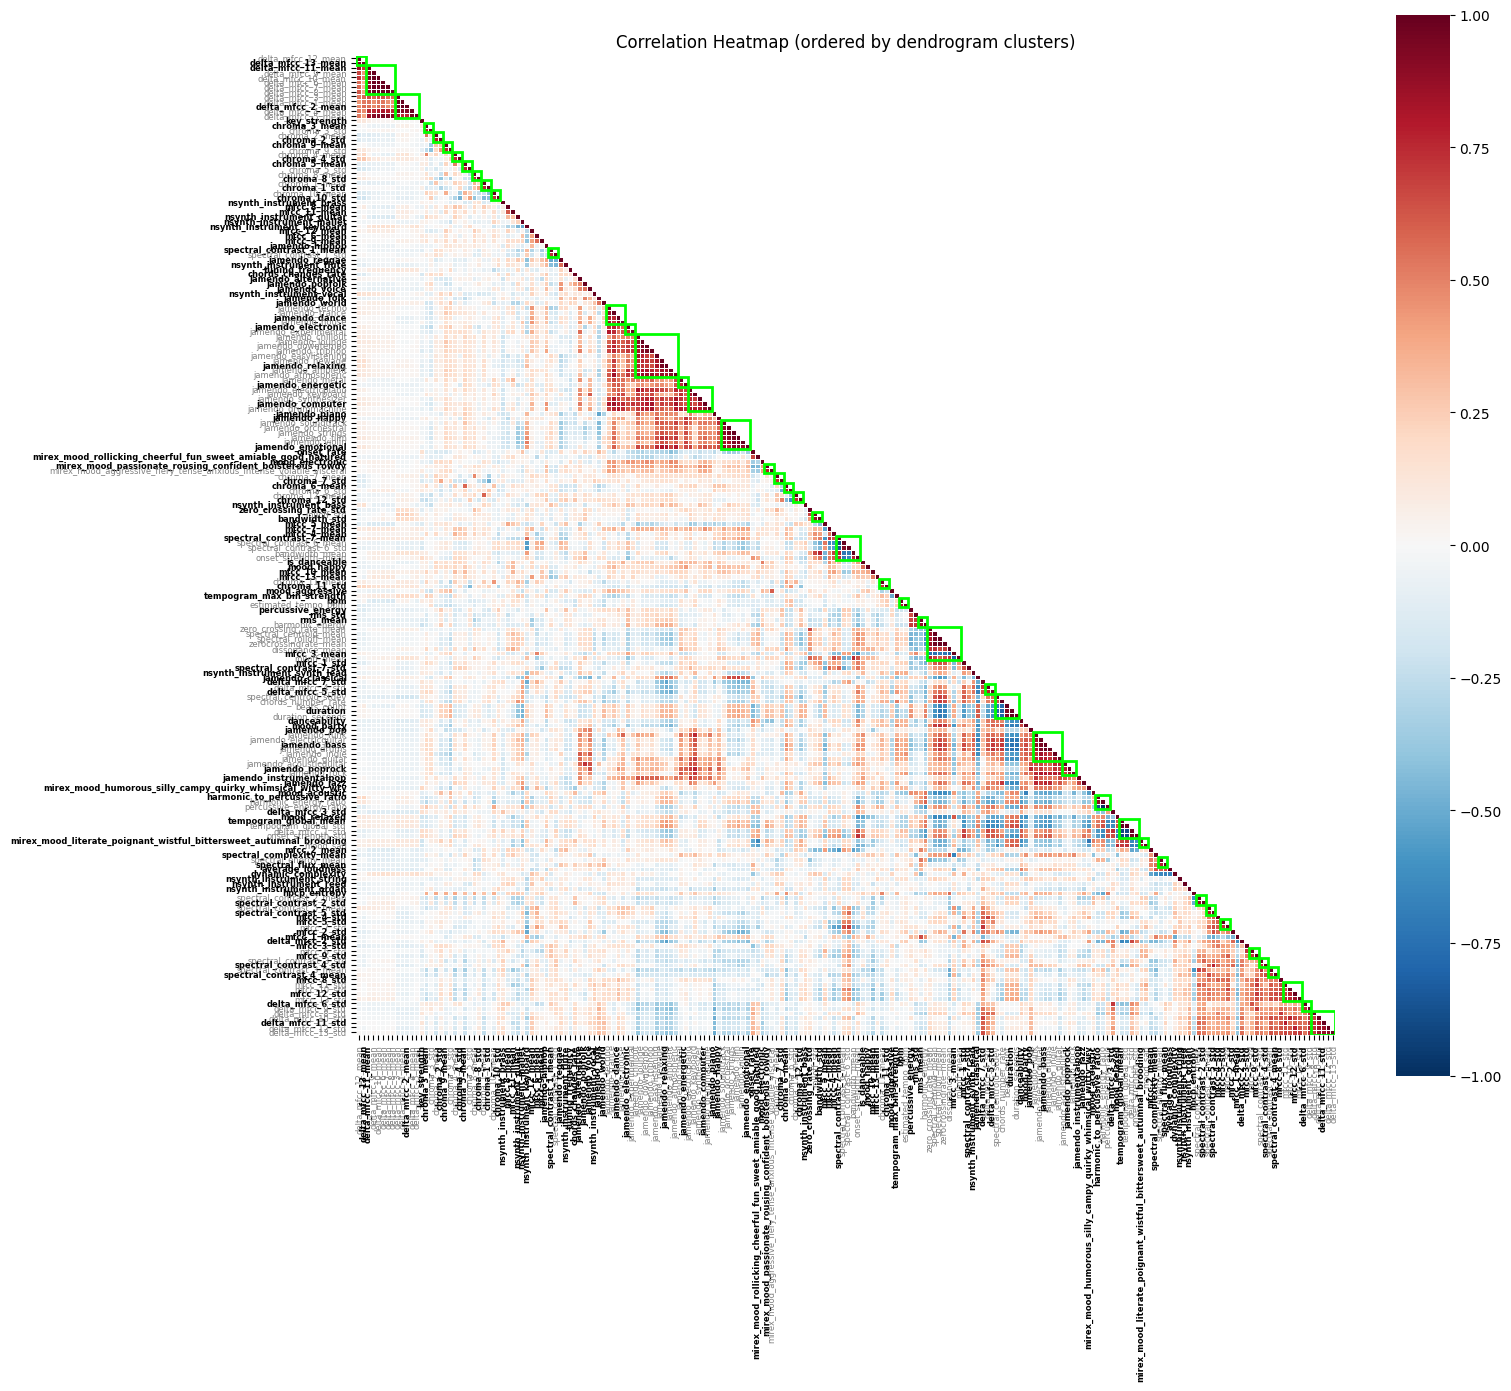

Bold labels = selected representatives (112)
Gray labels = dropped as redundant
Green boxes = multi-feature clusters (|r| > 0.7)


In [8]:
# 2c. Correlation heatmap ordered by dendrogram clusters
# Reuses link_full from 2b so features in the same cluster appear together
order = leaves_list(link_full)
ordered_features = [feature_names[i] for i in order]
corr_ordered = corr_full.loc[ordered_features, ordered_features]

fig, ax = plt.subplots(figsize=(16, 14))
mask_tri = np.zeros_like(corr_ordered, dtype=bool)
mask_tri[np.triu_indices_from(mask_tri, k=1)] = True
sns.heatmap(corr_ordered, mask=mask_tri, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, square=True, linewidths=0.5,
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title('Correlation Heatmap (ordered by dendrogram clusters)', fontsize=12)

# Bold the selected representative features on the y-axis
ytick_labels = ax.get_yticklabels()
for label in ytick_labels:
    label.set_fontsize(6)
    if label.get_text() in SELECTED_FEATURES:
        label.set_fontweight('bold')
        label.set_color('black')
    else:
        label.set_color('gray')
ax.set_yticklabels(ytick_labels)

xtick_labels = ax.get_xticklabels()
for label in xtick_labels:
    label.set_fontsize(6)
    if label.get_text() in SELECTED_FEATURES:
        label.set_fontweight('bold')
        label.set_color('black')
    else:
        label.set_color('gray')
ax.set_xticklabels(xtick_labels)

# Draw boxes around multi-feature clusters (correlated groups below threshold)
from matplotlib.patches import Rectangle
ordered_cluster_labels = [cluster_labels[feature_names.index(f)] for f in ordered_features]
n = len(ordered_features)
i = 0
while i < n:
    cid = ordered_cluster_labels[i]
    j = i
    while j < n and ordered_cluster_labels[j] == cid:
        j += 1
    size = j - i
    if size > 1:
        rect = Rectangle((i, i), size, size,
                          linewidth=2, edgecolor='lime', facecolor='none',
                          linestyle='-', zorder=5)
        ax.add_patch(rect)
    i = j

plt.tight_layout()
plt.show()

print(f'Bold labels = selected representatives ({len(SELECTED_FEATURES)})')
print(f'Gray labels = dropped as redundant')
print(f'Green boxes = multi-feature clusters (|r| > {1-CUT_THRESHOLD:.1f})')

# --- Original code (without cluster boxes) ---
# fig, ax = plt.subplots(figsize=(16, 14))
# mask_tri = np.zeros_like(corr_ordered, dtype=bool)
# mask_tri[np.triu_indices_from(mask_tri, k=1)] = True
# sns.heatmap(corr_ordered, mask=mask_tri, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
#             annot=False, square=True, linewidths=0.5,
#             xticklabels=True, yticklabels=True, ax=ax)
# ax.set_title('Correlation Heatmap (ordered by dendrogram clusters)', fontsize=12)
# ytick_labels = ax.get_yticklabels()
# for label in ytick_labels:
#     label.set_fontsize(6)
#     if label.get_text() in SELECTED_FEATURES:
#         label.set_fontweight('bold'); label.set_color('black')
#     else:
#         label.set_color('gray')
# ax.set_yticklabels(ytick_labels)
# xtick_labels = ax.get_xticklabels()
# for label in xtick_labels:
#     label.set_fontsize(6)
#     if label.get_text() in SELECTED_FEATURES:
#         label.set_fontweight('bold'); label.set_color('black')
#     else:
#         label.set_color('gray')
# ax.set_xticklabels(xtick_labels)
# plt.tight_layout(); plt.show()
# print(f'Bold labels = selected representatives ({len(SELECTED_FEATURES)})')
# print(f'Gray labels = dropped as redundant')

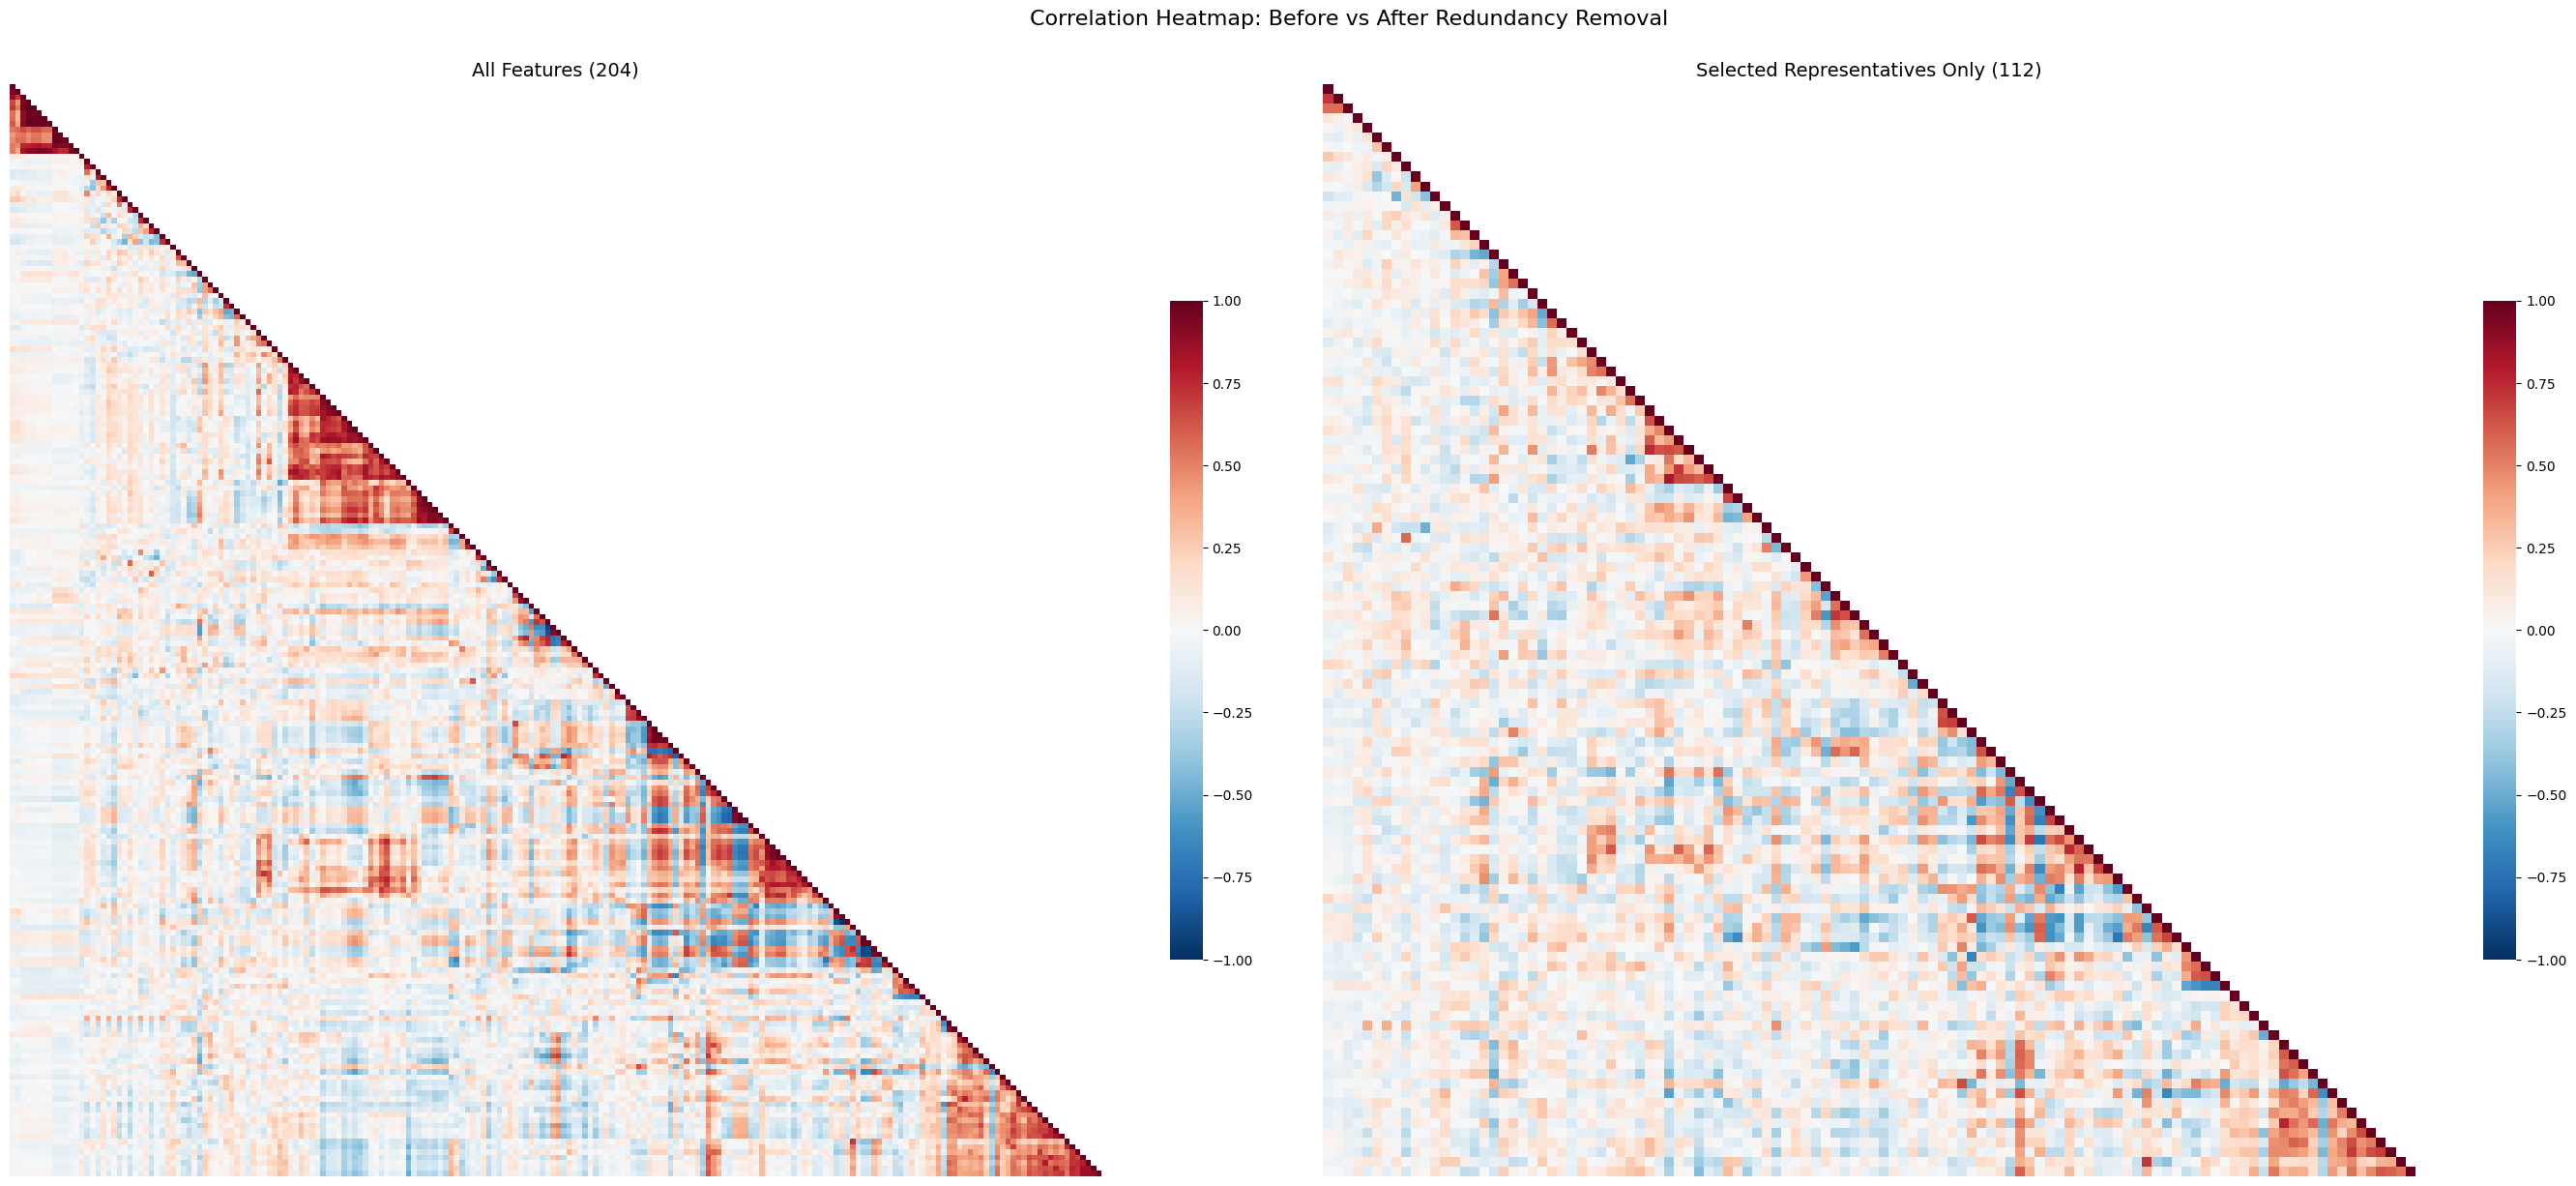

All features:      mean |r| = 0.165,  pairs with |r|>0.7: 133
Selected features: mean |r| = 0.150,  pairs with |r|>0.7: 1


In [9]:
# 2c-ii. Side-by-side comparison: all features vs selected-only
# Both use dendrogram leaf order so cluster neighbours stay together
ordered_selected = [f for f in ordered_features if f in SELECTED_FEATURES]
corr_all_ordered = corr_full.loc[ordered_features, ordered_features]
corr_sel_ordered = corr_full.loc[ordered_selected, ordered_selected]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(28, 12))

# Left: all features (dendrogram order)
mask1 = np.zeros_like(corr_all_ordered, dtype=bool)
mask1[np.triu_indices_from(mask1, k=1)] = True
sns.heatmap(corr_all_ordered, mask=mask1, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, square=True, linewidths=0,
            xticklabels=False, yticklabels=False, ax=ax1,
            cbar_kws={'shrink': 0.6})
ax1.set_title(f'All Features ({corr_all_ordered.shape[0]})', fontsize=14)

# Right: selected features only (same relative order from dendrogram)
mask2 = np.zeros_like(corr_sel_ordered, dtype=bool)
mask2[np.triu_indices_from(mask2, k=1)] = True
sns.heatmap(corr_sel_ordered, mask=mask2, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, square=True, linewidths=0,
            xticklabels=False, yticklabels=False, ax=ax2,
            cbar_kws={'shrink': 0.6})
ax2.set_title(f'Selected Representatives Only ({corr_sel_ordered.shape[0]})', fontsize=14)

plt.suptitle('Correlation Heatmap: Before vs After Redundancy Removal', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Stats comparison
off_diag_all = corr_all_ordered.values[np.tril_indices_from(corr_all_ordered.values, k=-1)]
off_diag_sel = corr_sel_ordered.values[np.tril_indices_from(corr_sel_ordered.values, k=-1)]
print(f'All features:      mean |r| = {np.abs(off_diag_all).mean():.3f},  pairs with |r|>{1-CUT_THRESHOLD}: {(np.abs(off_diag_all) > 0.8).sum()}')
print(f'Selected features: mean |r| = {np.abs(off_diag_sel).mean():.3f},  pairs with |r|>{1-CUT_THRESHOLD}: {(np.abs(off_diag_sel) > 0.8).sum()}')

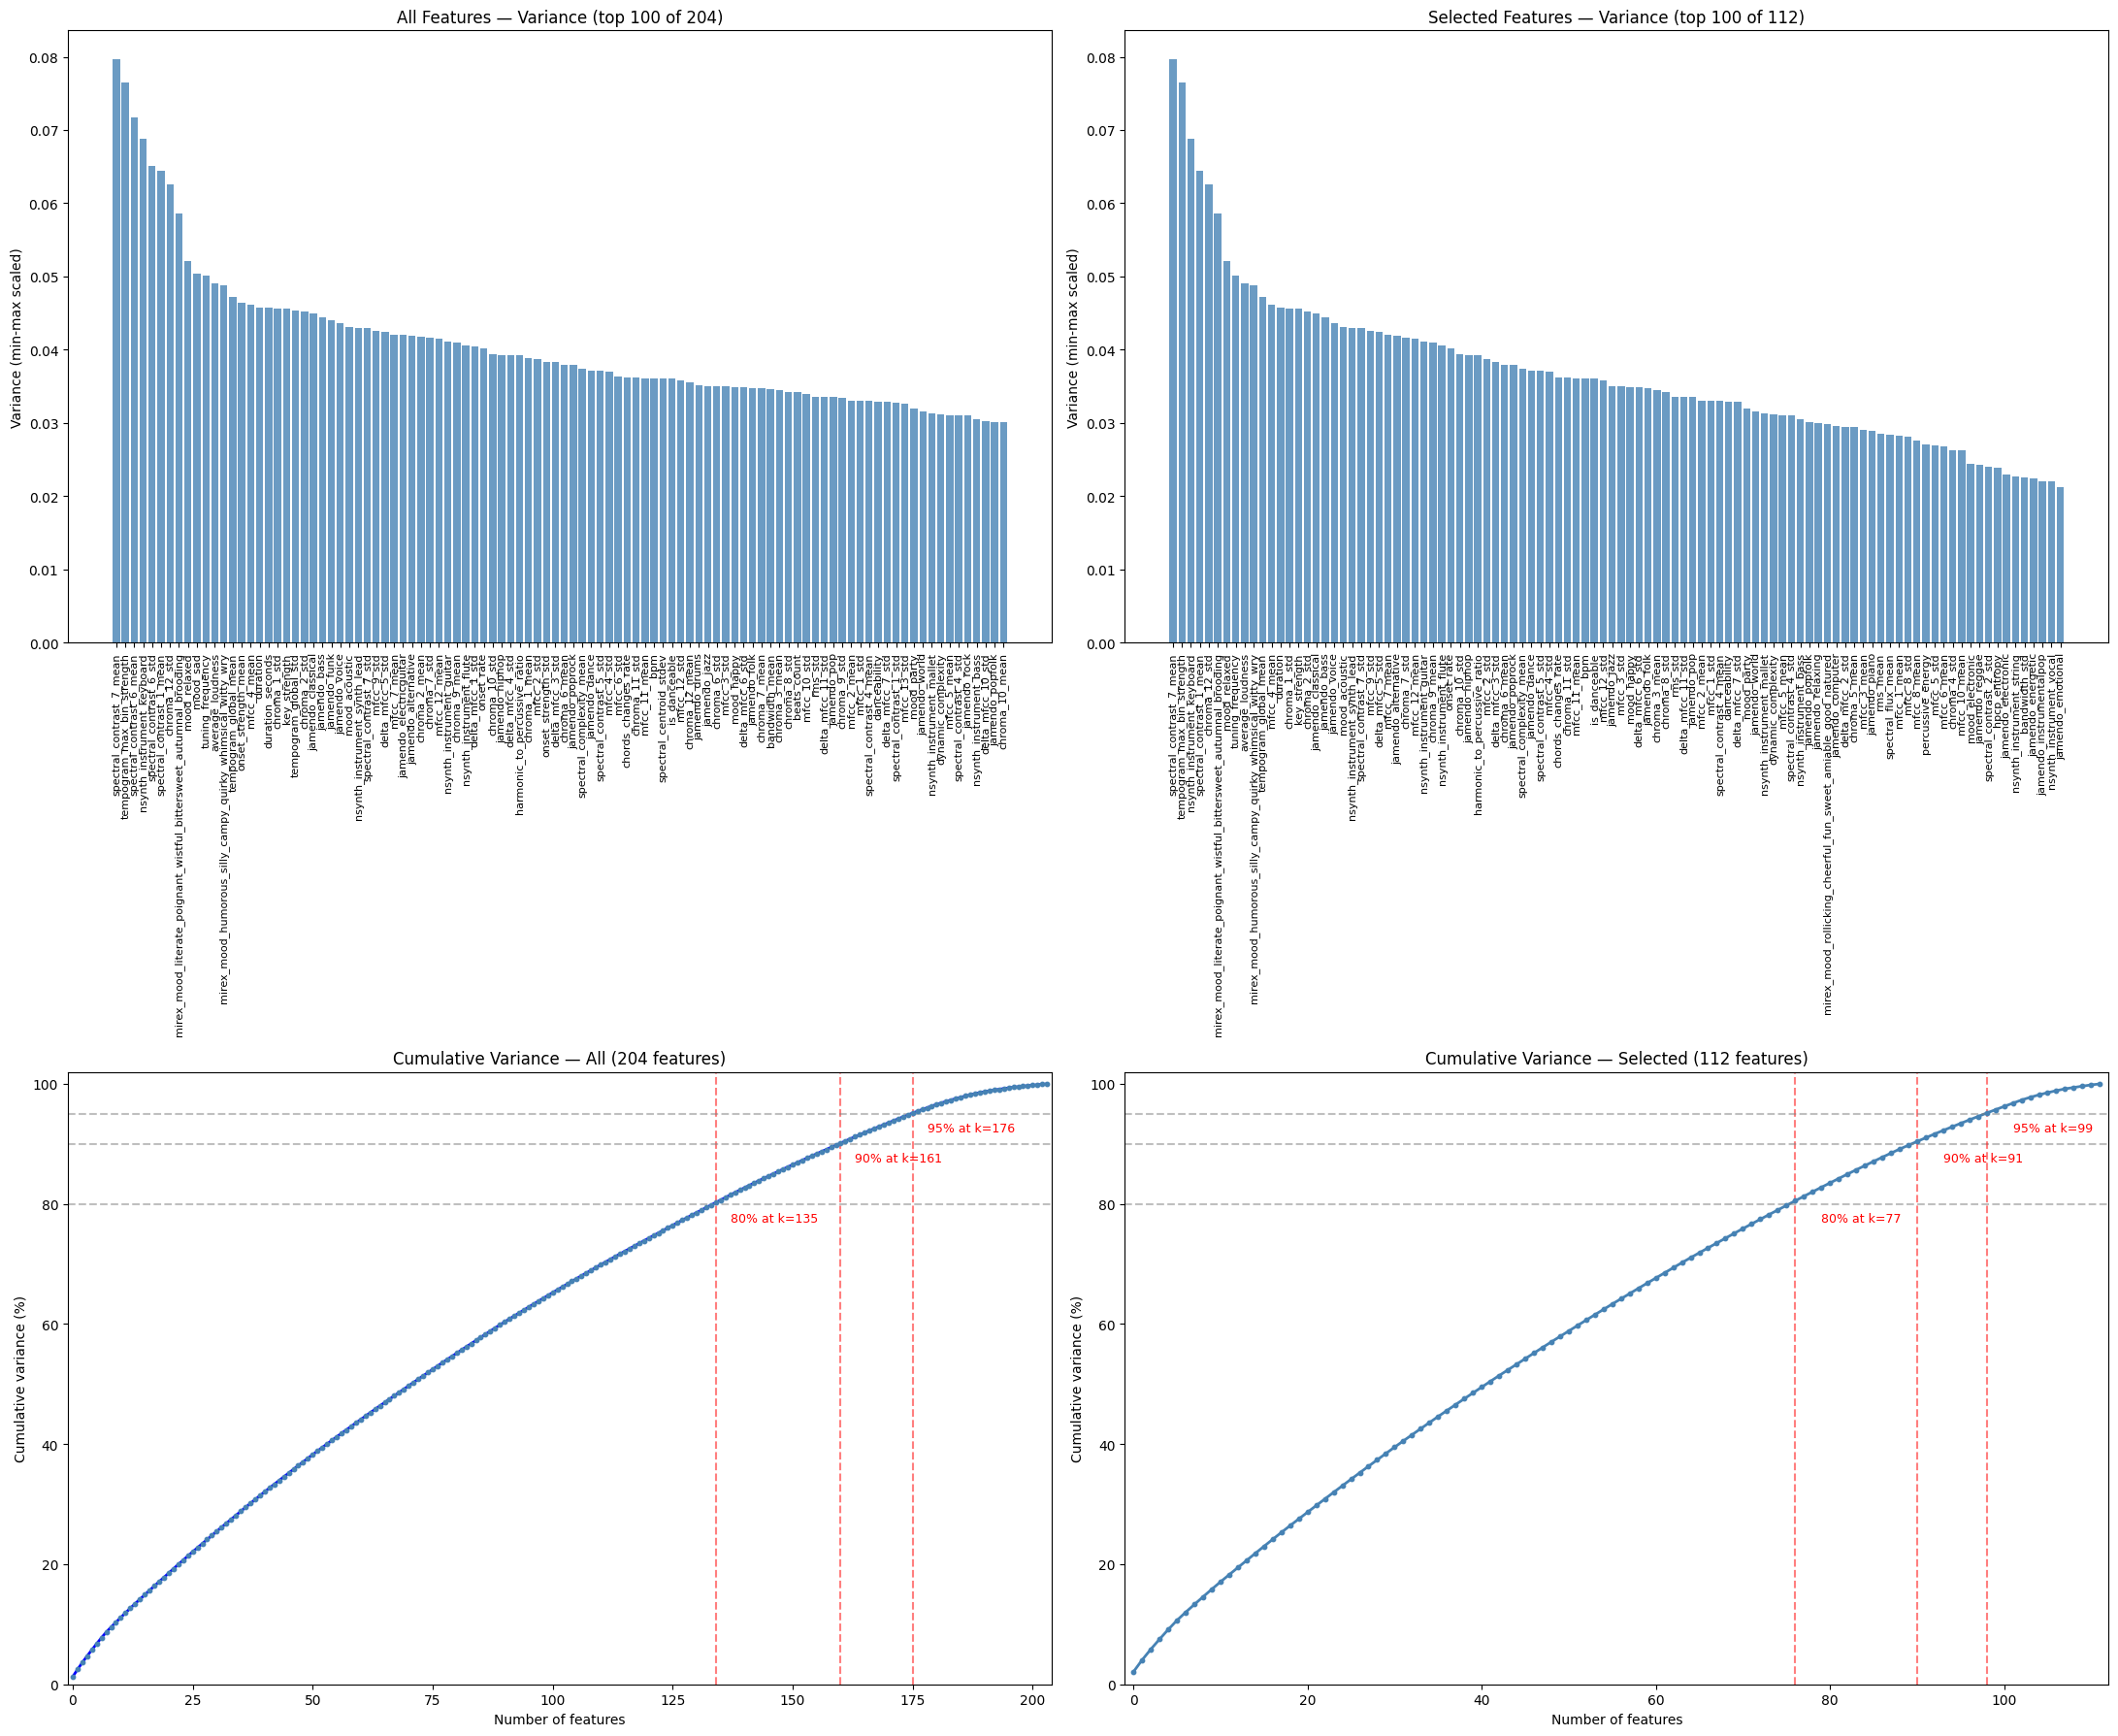

All features:      204 features, total variance = 6.2906
Selected features: 112 features, total variance = 3.8577
Variance retained: 61.3%

80% coverage: 135 features (all) vs 77 features (selected)
90% coverage: 161 features (all) vs 91 features (selected)
95% coverage: 176 features (all) vs 99 features (selected)


In [10]:
# 2d. Variance analysis — selected features only (redo of 2a)
# Compare variance distribution before and after redundancy removal

sel_variances = variances[variances.index.isin(SELECTED_FEATURES)].sort_values(ascending=False)
sel_scaled = feat_scaled[SELECTED_FEATURES]

fig, axes = plt.subplots(2, 2, figsize=(22, 18))

# Top-left: all features variance (original 2a)
top_n_all = min(100, len(variances))
colors_all = ['#FF9800' if variances.index[i] in binary_cols else 'steelblue' for i in range(top_n_all)]
axes[0, 0].bar(range(top_n_all), variances.values[:top_n_all], color=colors_all, alpha=0.8)
axes[0, 0].set_xticks(range(top_n_all))
axes[0, 0].set_xticklabels(variances.index[:top_n_all], rotation=90, fontsize=8)
axes[0, 0].set_ylabel('Variance (min-max scaled)')
axes[0, 0].set_title(f'All Features — Variance (top {top_n_all} of {len(variances)})')

# Top-right: selected features variance
top_n_sel = min(100, len(sel_variances))
colors_sel = ['#FF9800' if sel_variances.index[i] in binary_cols else 'steelblue' for i in range(top_n_sel)]
axes[0, 1].bar(range(top_n_sel), sel_variances.values[:top_n_sel], color=colors_sel, alpha=0.8)
axes[0, 1].set_xticks(range(top_n_sel))
axes[0, 1].set_xticklabels(sel_variances.index[:top_n_sel], rotation=90, fontsize=8)
axes[0, 1].set_ylabel('Variance (min-max scaled)')
axes[0, 1].set_title(f'Selected Features — Variance (top {top_n_sel} of {len(sel_variances)})')

# Bottom-left: cumulative variance (all)
cum_var_all = variances.cumsum() / variances.sum() * 100
axes[1, 0].plot(range(len(cum_var_all)), cum_var_all.values, 'b-', linewidth=2)
axes[1, 0].scatter(range(len(cum_var_all)), cum_var_all.values, s=10, color='steelblue', zorder=3)
for t in [80, 90, 95]:
    idx = np.searchsorted(cum_var_all.values, t)
    if idx < len(cum_var_all):
        axes[1, 0].axhline(y=t, color='gray', linestyle='--', alpha=0.5)
        axes[1, 0].axvline(x=idx, color='red', linestyle='--', alpha=0.5)
        axes[1, 0].annotate(f'{t}% at k={idx+1}', xy=(idx, t),
                            xytext=(idx+3, t-3), fontsize=9, color='red')
axes[1, 0].set_xlabel('Number of features')
axes[1, 0].set_ylabel('Cumulative variance (%)')
axes[1, 0].set_title(f'Cumulative Variance — All ({len(variances)} features)')
axes[1, 0].set_xlim(-1, len(cum_var_all))
axes[1, 0].set_ylim(0, 102)

# Bottom-right: cumulative variance (selected only)
cum_var_sel = sel_variances.cumsum() / sel_variances.sum() * 100
axes[1, 1].plot(range(len(cum_var_sel)), cum_var_sel.values, '-', color='steelblue', linewidth=2)
axes[1, 1].scatter(range(len(cum_var_sel)), cum_var_sel.values, s=10, color='steelblue', zorder=3)
for t in [80, 90, 95]:
    idx = np.searchsorted(cum_var_sel.values, t)
    if idx < len(cum_var_sel):
        axes[1, 1].axhline(y=t, color='gray', linestyle='--', alpha=0.5)
        axes[1, 1].axvline(x=idx, color='red', linestyle='--', alpha=0.5)
        axes[1, 1].annotate(f'{t}% at k={idx+1}', xy=(idx, t),
                            xytext=(idx+3, t-3), fontsize=9, color='red')
axes[1, 1].set_xlabel('Number of features')
axes[1, 1].set_ylabel('Cumulative variance (%)')
axes[1, 1].set_title(f'Cumulative Variance — Selected ({len(sel_variances)} features)')
axes[1, 1].set_xlim(-1, len(cum_var_sel))
axes[1, 1].set_ylim(0, 102)

plt.tight_layout()
plt.show()

# Summary stats
print(f'All features:      {len(variances)} features, total variance = {variances.sum():.4f}')
print(f'Selected features: {len(sel_variances)} features, total variance = {sel_variances.sum():.4f}')
print(f'Variance retained: {sel_variances.sum() / variances.sum() * 100:.1f}%')
print()
for t in [80, 90, 95]:
    k_all = np.searchsorted(cum_var_all.values, t) + 1
    k_sel = np.searchsorted(cum_var_sel.values, t) + 1
    print(f'{t}% coverage: {k_all} features (all) vs {k_sel} features (selected)')

In [11]:
# 2e. Keep only features covering partial cumulative variance + restore categoricals
VARIANCE_THRESHOLD = 90  # percent

# Find the cutoff index in the sorted selected-feature variances
cutoff_idx = np.searchsorted(cum_var_sel.values, VARIANCE_THRESHOLD) + 1
top_var_features = sel_variances.index[:cutoff_idx].tolist()

dropped = [f for f in SELECTED_FEATURES if f not in top_var_features]

print(f'Variance threshold: {VARIANCE_THRESHOLD}%')
print(f'Audio features kept:  {len(top_var_features)} / {len(SELECTED_FEATURES)}')
print(f'Audio features dropped: {len(dropped)}')
print(f'\nDropped features:\n{dropped}')

# Update SELECTED_FEATURES (audio only at this point)
SELECTED_FEATURES = top_var_features

# Add CATEGORICAL_COLS back — they bypass feature selection entirely
SELECTED_FEATURES = CATEGORICAL_COLS + SELECTED_FEATURES

print(f'\nFinal SELECTED_FEATURES: {len(SELECTED_FEATURES)} total')
print(f'  CATEGORICAL_COLS: {len(CATEGORICAL_COLS)} ({CATEGORICAL_COLS})')
print(f'  Audio features: {len(SELECTED_FEATURES) - len(CATEGORICAL_COLS)}')

Variance threshold: 90%
Audio features kept:  91 / 112
Audio features dropped: 21

Dropped features:
['spectral_contrast_2_std', 'hpcp_entropy', 'jamendo_electronic', 'nsynth_instrument_string', 'bandwidth_std', 'jamendo_energetic', 'jamendo_instrumentalpop', 'nsynth_instrument_vocal', 'jamendo_emotional', 'mfcc_9_mean', 'mirex_mood_passionate_rousing_confident_boisterous_rowdy', 'mfcc_13_mean', 'nsynth_instrument_organ', 'jamendo_happy', 'nsynth_instrument_reed', 'zero_crossing_rate_std', 'mood_aggressive', 'delta_mfcc_13_mean', 'delta_mfcc_2_mean', 'nsynth_instrument_brass', 'delta_mfcc_11_mean']

Final SELECTED_FEATURES: 99 total
  CATEGORICAL_COLS: 8 (['album', 'filename', 'style', 'decade', 'orchestra', 'singer', 'key', 'scale'])
  Audio features: 91


## 3. Feature Catalog & Descriptions

Group features by semantic category, informed by the EDA above.
This catalog serves two purposes:
1. Tell the LLM what features exist and what they mean (Methods 2A/2B)
2. Define the interpretable feature set for the small model (Method 3)

In [12]:
# FULL Feature catalog: group_name -> list of (column_name, description)
# Covers ALL features from Essentia, Librosa, and derived metadata columns.
# NOTE: Feature descriptions below are AI-generated approximations.
# They have NOT been verified against the official essentia/librosa documentation.
# Consult the library docs for precise definitions.
FEATURE_CATALOG = {
    # ── Rhythm & Tempo ──
    'rhythm': [
        ('bpm', 'Beats per minute — tempo of the track (Essentia)'),
        ('estimated_tempo_bpm', 'Estimated tempo in BPM (Librosa)'),
        ('onset_rate', 'Number of note onsets per second — rhythmic density'),
        ('onset_strength_mean', 'Mean onset detection strength — attack prominence'),
        ('onset_strength_std', 'Onset strength variation over time'),
        ('beats_count', 'Total number of detected beats'),
        ('duration', 'Track duration in seconds (Essentia)'),
        ('duration_seconds', 'Track duration in seconds (Librosa)'),
        ('tempogram_global_mean', 'Mean tempogram value — tempo stability'),
        ('tempogram_global_std', 'Tempogram variation — tempo fluctuation'),
        ('tempogram_max_bin_strength', 'Strength of dominant tempo bin in tempogram'),
    ],

    # ── Energy & Dynamics ──
    'energy': [
        ('average_loudness', 'Mean loudness level (0-1)'),
        ('dynamic_complexity', 'How much loudness varies — higher = more dynamic'),
        ('rms_mean', 'Root mean square energy — overall volume level'),
        ('rms_std', 'RMS standard deviation — energy variation over time'),
        ('spectral_energy_mean', 'Mean spectral energy — total frequency-domain power'),
    ],

    # ── Mood (Essentia classifiers) ──
    'mood': [
        ('mood_happy', 'Happiness probability (0-1)'),
        ('mood_sad', 'Sadness probability (0-1)'),
        ('mood_relaxed', 'Relaxation probability (0-1)'),
        ('mood_aggressive', 'Aggressiveness probability (0-1)'),
        ('mood_party', 'Party/upbeat probability (0-1)'),
        ('mood_acoustic', 'Acoustic quality probability (0-1)'),
        ('mood_electronic', 'Electronic sound probability (0-1)'),
    ],

    # ── MIREX Mood (Essentia, multi-label) ──
    'mirex_mood': [
        ('mirex_mood_passionate_rousing_confident_boisterous_rowdy',
         'MIREX cluster 1 — passionate / rousing / confident / boisterous'),
        ('mirex_mood_rollicking_cheerful_fun_sweet_amiable_good_natured',
         'MIREX cluster 2 — cheerful / fun / sweet / amiable'),
        ('mirex_mood_literate_poignant_wistful_bittersweet_autumnal_brooding',
         'MIREX cluster 3 — poignant / wistful / bittersweet / brooding'),
        ('mirex_mood_humorous_silly_campy_quirky_whimsical_witty_wry',
         'MIREX cluster 4 — humorous / silly / quirky / whimsical'),
        ('mirex_mood_aggressive_fiery_tense_anxious_intense_volatile_visceral',
         'MIREX cluster 5 — aggressive / fiery / tense / intense'),
    ],

    # ── Spectral shape ──
    'spectral': [
        ('spectral_centroid_mean', 'Brightness — higher = brighter/more treble (Essentia)'),
        ('spectral_centroid_stdev', 'Spectral centroid variation (Essentia)'),
        ('spectral_rolloff_mean', 'Frequency below which most energy lies (Essentia)'),
        ('spectral_complexity_mean', 'Number of spectral peaks — timbral richness'),
        ('spectral_flux_mean', 'Rate of spectral change over time'),
        ('bandwidth_mean', 'Spectral bandwidth — frequency spread'),
        ('bandwidth_std', 'Spectral bandwidth variation'),
        ('rolloff_mean', 'Spectral roll-off frequency mean (Librosa)'),
        ('rolloff_std', 'Spectral roll-off frequency variation (Librosa)'),
        ('zerocrossingrate_mean', 'Zero crossing rate — noisiness/percussiveness (Essentia)'),
        ('zero_crossing_rate_mean', 'Zero crossing rate mean (Librosa)'),
        ('zero_crossing_rate_std', 'Zero crossing rate variation (Librosa)'),
        ('dissonance_mean', 'Mean sensory dissonance — harmonic roughness'),
    ],

    # ── Spectral Contrast (Librosa, 7 bands) ──
    'spectral_contrast': [
        (f'spectral_contrast_{i}_mean', f'Spectral contrast band {i} mean — peak-valley difference')
        for i in range(1, 8)
    ] + [
        (f'spectral_contrast_{i}_std', f'Spectral contrast band {i} variation')
        for i in range(1, 8)
    ],

    # ── MFCC (Librosa, 13 coefficients) ──
    'mfcc': [
        (f'mfcc_{i}_mean', f'MFCC coefficient {i} mean — timbre component {i}')
        for i in range(1, 14)
    ] + [
        (f'mfcc_{i}_std', f'MFCC coefficient {i} std — timbre stability {i}')
        for i in range(1, 14)
    ],

    # ── Delta MFCC (Librosa, 13 coefficients) ──
    'delta_mfcc': [
        (f'delta_mfcc_{i}_mean', f'Delta MFCC {i} mean — rate of timbre change {i}')
        for i in range(1, 14)
    ] + [
        (f'delta_mfcc_{i}_std', f'Delta MFCC {i} std — timbre change variability {i}')
        for i in range(1, 14)
    ],

    # ── Chroma / Harmony (Librosa, 12 pitch classes) ──
    'chroma': [
        (f'chroma_{i}_mean', f'Chroma {i} mean — pitch class {i} energy')
        for i in range(1, 13)
    ] + [
        (f'chroma_{i}_std', f'Chroma {i} std — pitch class {i} variation')
        for i in range(1, 13)
    ],

    # ── Harmony (Essentia) ──
    'harmony': [
        ('key_strength', 'Confidence of key detection (0-1)'),
        ('chords_changes_rate', 'Rate of chord changes per second'),
        ('chords_number_rate', 'Rate of distinct chord types per second'),
        ('hpcp_entropy', 'Harmonic pitch class entropy — tonal complexity'),
        ('tuning_frequency', 'Estimated tuning reference frequency (Hz)'),
    ],

    # ── Texture / Harmonic-Percussive ──
    'texture': [
        ('harmonic_energy', 'Total harmonic (tonal) energy'),
        ('harmonic_energy_ratio', 'Fraction of total energy that is harmonic'),
        ('percussive_energy', 'Total percussive energy'),
        ('percussive_energy_ratio', 'Fraction of total energy that is percussive'),
        ('harmonic_to_percussive_ratio', 'Harmonic/percussive balance — higher = more tonal'),
    ],

    # ── Danceability ──
    'danceability': [
        ('danceability', 'Algorithmic danceability score (0-1)'),
        ('is_danceable', 'Binary danceability classification confidence'),
    ],

    # ── Instrument Detection (Essentia Nsynth model) ──
    'nsynth_instrument': [
        ('nsynth_instrument_bass', 'Probability of bass instrument (0-1)'),
        ('nsynth_instrument_brass', 'Probability of brass instrument (0-1)'),
        ('nsynth_instrument_flute', 'Probability of flute (0-1)'),
        ('nsynth_instrument_guitar', 'Probability of guitar (0-1)'),
        ('nsynth_instrument_keyboard', 'Probability of keyboard (0-1)'),
        ('nsynth_instrument_mallet', 'Probability of mallet instrument (0-1)'),
        ('nsynth_instrument_organ', 'Probability of organ (0-1)'),
        ('nsynth_instrument_reed', 'Probability of reed instrument (0-1)'),
        ('nsynth_instrument_string', 'Probability of string instrument (0-1)'),
        ('nsynth_instrument_synth_lead', 'Probability of synth lead (0-1)'),
        ('nsynth_instrument_vocal', 'Probability of vocal (0-1)'),
    ],

    # ── Jamendo Genre/Tag Activations (Essentia) ──
    'jamendo': [
        ('jamendo_acousticguitar', 'Acoustic guitar tag activation'),
        ('jamendo_alternative', 'Alternative tag activation'),
        ('jamendo_ambient', 'Ambient tag activation'),
        ('jamendo_atmospheric', 'Atmospheric tag activation'),
        ('jamendo_bass', 'Bass tag activation'),
        ('jamendo_chillout', 'Chillout tag activation'),
        ('jamendo_classical', 'Classical tag activation'),
        ('jamendo_computer', 'Computer/electronic-production tag activation'),
        ('jamendo_dance', 'Dance tag activation'),
        ('jamendo_downtempo', 'Downtempo tag activation'),
        ('jamendo_drummachine', 'Drum machine tag activation'),
        ('jamendo_drums', 'Drums tag activation'),
        ('jamendo_easylistening', 'Easy listening tag activation'),
        ('jamendo_electricguitar', 'Electric guitar tag activation'),
        ('jamendo_electricpiano', 'Electric piano tag activation'),
        ('jamendo_electronic', 'Electronic tag activation'),
        ('jamendo_emotional', 'Emotional tag activation'),
        ('jamendo_energetic', 'Energetic tag activation'),
        ('jamendo_experimental', 'Experimental tag activation'),
        ('jamendo_film', 'Film/cinematic tag activation'),
        ('jamendo_folk', 'Folk tag activation'),
        ('jamendo_funk', 'Funk tag activation'),
        ('jamendo_guitar', 'Guitar tag activation'),
        ('jamendo_happy', 'Happy tag activation'),
        ('jamendo_hiphop', 'Hip-hop tag activation'),
        ('jamendo_house', 'House tag activation'),
        ('jamendo_indie', 'Indie tag activation'),
        ('jamendo_instrumentalpop', 'Instrumental pop tag activation'),
        ('jamendo_jazz', 'Jazz tag activation'),
        ('jamendo_keyboard', 'Keyboard tag activation'),
        ('jamendo_lounge', 'Lounge tag activation'),
        ('jamendo_metal', 'Metal tag activation'),
        ('jamendo_newage', 'New age tag activation'),
        ('jamendo_orchestral', 'Orchestral tag activation'),
        ('jamendo_piano', 'Piano tag activation'),
        ('jamendo_pop', 'Pop tag activation'),
        ('jamendo_popfolk', 'Pop-folk tag activation'),
        ('jamendo_poprock', 'Pop-rock tag activation'),
        ('jamendo_reggae', 'Reggae tag activation'),
        ('jamendo_relaxing', 'Relaxing tag activation'),
        ('jamendo_rock', 'Rock tag activation'),
        ('jamendo_soundtrack', 'Soundtrack tag activation'),
        ('jamendo_strings', 'Strings tag activation'),
        ('jamendo_synthesizer', 'Synthesizer tag activation'),
        ('jamendo_techno', 'Techno tag activation'),
        ('jamendo_trance', 'Trance tag activation'),
        ('jamendo_triphop', 'Trip-hop tag activation'),
        ('jamendo_violin', 'Violin tag activation'),
        ('jamendo_voice', 'Voice/vocal tag activation'),
        ('jamendo_world', 'World music tag activation'),
    ],

    'categorical': [
       ('album', 'Album or collection name the track belongs to'),
       ('filename', 'Audio filename — unique track identifier'),
       ('style', 'Tango dance style: tango, vals, milonga, or cortina'),
       ('decade', 'Recording decade (e.g. "1940s")'),
       ('orchestra', 'Performing orchestra name'),
       ('singer', 'Vocalist name (NaN = instrumental)'),
       ('key', 'Detected musical key (e.g. "C", "Dm") — Essentia key detection'),
       ('scale', 'Detected scale type: major or minor — Essentia key detection'),
   ],

    # ── Technical / non-feature (included for completeness, usually excluded) ──
    'technical': [
        ('sample_rate', 'Audio sample rate in Hz'),
    ],
}

In [13]:
# Flatten to get all feature names
ALL_FEATURE_NAMES = []
FEATURE_DESC_MAP = {}  # feature_name -> description
for group, features in FEATURE_CATALOG.items():
    for fname, fdesc in features:
        ALL_FEATURE_NAMES.append(fname)
        FEATURE_DESC_MAP[fname] = fdesc

# Filter to features that actually exist in our merged dataframe
AVAILABLE_FEATURES = [f for f in ALL_FEATURE_NAMES if f in df_merged.columns]
MISSING_FEATURES = [f for f in ALL_FEATURE_NAMES if f not in df_merged.columns]

# Check for columns in df_merged that are NOT in the catalog (catch new/unexpected cols)
all_in_df = [c for c in df_merged.columns if not c.startswith('Unnamed')]
UNCATALOGUED = [c for c in all_in_df if c not in ALL_FEATURE_NAMES]

print(f'Catalog defines {len(ALL_FEATURE_NAMES)} features across {len(FEATURE_CATALOG)} groups')
print(f'Available in merged df: {len(AVAILABLE_FEATURES)}')
if MISSING_FEATURES:
    print(f'Missing from df ({len(MISSING_FEATURES)}): {MISSING_FEATURES}')
if UNCATALOGUED:
    print(f'In df but NOT in catalog ({len(UNCATALOGUED)}): {UNCATALOGUED}')
else:
    print('All columns in df_merged are catalogued.')

# Per-group summary
print(f'\n{"Group":20s} {"Defined":>8s} {"Available":>10s}')
print('-' * 40)
for group, features in FEATURE_CATALOG.items():
    n_def = len(features)
    n_avail = sum(1 for f, _ in features if f in df_merged.columns)
    print(f'{group:20s} {n_def:8d} {n_avail:10d}')

# Filter catalog to only SELECTED_FEATURES
SELECTED_CATALOG = {}
for group, features in FEATURE_CATALOG.items():
    if group == 'categorical':
        # Categorical columns always included
        selected = [(f, d) for f, d in features if f in CATEGORICAL_COLS]
    else:
        selected = [(f, d) for f, d in features if f in SELECTED_FEATURES]
    if selected:
        SELECTED_CATALOG[group] = selected

print(f'\nFiltered catalog: {sum(len(v) for v in SELECTED_CATALOG.values())} features across {len(SELECTED_CATALOG)} groups')

Catalog defines 213 features across 16 groups
Available in merged df: 213
All columns in df_merged are catalogued.

Group                 Defined  Available
----------------------------------------
rhythm                     11         11
energy                      5          5
mood                        7          7
mirex_mood                  5          5
spectral                   13         13
spectral_contrast          14         14
mfcc                       26         26
delta_mfcc                 26         26
chroma                     24         24
harmony                     5          5
texture                     5          5
danceability                2          2
nsynth_instrument          11         11
jamendo                    50         50
categorical                 8          8
technical                   1          1

Filtered catalog: 99 features across 15 groups


In [14]:
def build_feature_description_prompt(df: pd.DataFrame, feature_catalog: dict) -> str:
    """Build a prompt section describing all available features with observed stats."""
    lines = []
    for group, features in feature_catalog.items():
        lines.append(f'\n### {group.upper()} FEATURES')
        for fname, fdesc in features:
            if fname not in df.columns:
                continue
            col = df[fname]
            if col.dtype in ['float64', 'float32', 'int64']:
                stats_str = f'range [{col.min():.4f}, {col.max():.4f}], mean={col.mean():.4f}'
            else:
                stats_str = f'categorical, {col.nunique()} unique values'
            lines.append(f'- **{fname}**: {fdesc} | {stats_str}')
    return '\n'.join(lines)

SELECTED_FEATURE_PROMPT = build_feature_description_prompt(df_merged, SELECTED_CATALOG)
print(SELECTED_FEATURE_PROMPT[:2000])
print(f'\n... ({len(SELECTED_FEATURE_PROMPT)} chars total)')


### RHYTHM FEATURES
- **bpm**: Beats per minute — tempo of the track (Essentia) | range [90.3331, 178.2060], mean=123.6364
- **onset_rate**: Number of note onsets per second — rhythmic density | range [1.9566, 4.5675], mean=3.3597
- **duration**: Track duration in seconds (Essentia) | range [33.1233, 218.5665], mean=158.9058
- **tempogram_global_mean**: Mean tempogram value — tempo stability | range [0.1503, 0.2688], mean=0.2205
- **tempogram_max_bin_strength**: Strength of dominant tempo bin in tempogram | range [0.9798, 1.0000], mean=0.9884

### ENERGY FEATURES
- **average_loudness**: Mean loudness level (0-1) | range [0.0451, 0.9522], mean=0.6405
- **dynamic_complexity**: How much loudness varies — higher = more dynamic | range [2.3583, 9.2936], mean=5.2727
- **rms_mean**: Root mean square energy — overall volume level | range [0.0568, 0.1938], mean=0.1056
- **rms_std**: RMS standard deviation — energy variation over time | range [0.0323, 0.0980], mean=0.0631

### MOOD FEATURES
- *

## 4. Save Artifacts

Export df_merged, feature catalog, and feature prompt for downstream notebooks (02b-02d).

In [15]:
import pickle

FEATURES_DIR = Path(PROCESSED_DIR) / 'features_exp'
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

df_merged.to_pickle(FEATURES_DIR / 'df_merged.pkl')
print(f'Saved df_merged.pkl ({df_merged.shape})')

with open(FEATURES_DIR / 'feature_catalog.pkl', 'wb') as f:
    pickle.dump(SELECTED_CATALOG, f)
print('Saved feature_catalog.pkl')

with open(FEATURES_DIR / 'feature_prompt.txt', 'w', encoding='utf-8') as f:
    f.write(SELECTED_FEATURE_PROMPT)
print(f'Saved feature_prompt.txt ({len(SELECTED_FEATURE_PROMPT)} chars)')

Saved df_merged.pkl ((184, 213))
Saved feature_catalog.pkl
Saved feature_prompt.txt (10380 chars)
